# MPNNs: message, aggregate, update, readout

Self-contained student lab: implement routing, verify symmetry, then inspect the full molecular reconstruction. Core exercises need PyTorch; the optional QM9 lane also uses RDKit and PyG.

In [ ]:
# @colab-bootstrap
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch-geometric==2.6.1','rdkit==2025.9.6'])
import torch
print('Runtime torch:',torch.__version__)

## Start cold · what must move when a node is renamed?

**Cold recall:** write your answers in a markdown cell before reading further.

Close your notes. In the chain A—B—C, can changing C affect A after one synchronous neighbor update? If rows are reordered, what else must be reordered? Why is validation allowed to choose a model while the test set is not? Write answers before continuing.

**Your tangible win:** implement message → aggregate → update → readout, and show that renaming nodes changes their positions rather than the graph prediction. The core takes about 30 minutes; reserve another session for the molecular model and reproduction audit.

[Lesson 78](https://avistian.github.io/relational/lessons/0078-message-passing-preview.html) made one neighbor calculation concrete. [Lesson 80](https://avistian.github.io/relational/lessons/0080-year-2-exit-exam.html) demanded a defensible experiment. Year 3 combines these skills: make graph operations explicit, then test what the resulting model actually learns. This is the foundation for learning over entity relationships in a database.

**Primary reading:** Gilmer et al., [Neural Message Passing for Quantum Chemistry](https://proceedings.mlr.press/v70/gilmer17a.html), §2 for the framework and §§6–8 for the experiment. Read the [supplement](https://proceedings.mlr.press/v70/gilmer17a/gilmer17a-supp.pdf), Table 3, after the core lab.

## 1 · Four operations, one contract

> **In plain terms.** A node asks its neighbors for information, combines their replies, and revises its state. A final readout combines node states when the prediction belongs to the whole graph.

**State.** A node state hᵗᵥ is a vector describing node v after t rounds. Initially it contains or encodes the node's observed features. N nodes with D coordinates form a matrix H of shape [N,D].

**Message.** For a directed edge w → v, Mₜ(hᵗᵥ, hᵗ𝑤, eᵥ𝑤) constructs the information sent from source w to destination v. The edge feature e can encode a bond type, a transaction amount, or a relation type. Do not swap source and destination merely because an example graph is undirected.

**Aggregate.** Combine all incoming messages at a destination. The paper's basic definition uses a sum:

```text
mᵗ⁺¹ᵥ = Σ over w in N(v) Mₜ(hᵗᵥ, hᵗ𝑤, eᵥ𝑤)
```

Sum ignores the order of incoming edges. Mean also ignores order, but divides away neighborhood size. For example, messages [2,2] and [2,2,2] have the same mean; their sums are 4 and 6. Neither reducer identifies every possible multiset: [1,3] and [2,2] have equal sums. The choice encodes what information survives.

**Update.** Set hᵗ⁺¹ᵥ = Uₜ(hᵗᵥ, mᵗ⁺¹ᵥ). Every message in round t+1 uses the old state Hᵗ. Updating a Python list in place while traversing nodes would let later nodes see newer information and make the result depend on iteration order.

**Readout.** For a graph target, ŷ = R({hᵀᵥ}). A sum or an invariant learned readout discards arbitrary node order. For a node target, keep one output per node. Pooling all nodes would destroy the distinction between their predictions. These are the message-passing and readout phases of [Gilmer §2](https://proceedings.mlr.press/v70/gilmer17a/gilmer17a.pdf).

## 2 · Trace the operation before coding it

**Worked example.** Use A—B—C plus isolated node D. Start with [2,4,8,10]. Send the old scalar state along each direction of each bond. Take the mean of incoming messages, then average it with the destination's old state. Define an empty neighborhood's aggregate as zero.

**Predict first:** compute B before reading the trace below.

<figure class="mpnn-figure"><small>Scroll horizontally on narrow screens to inspect the full figure.</small><div class="figure-scroll" tabindex="0">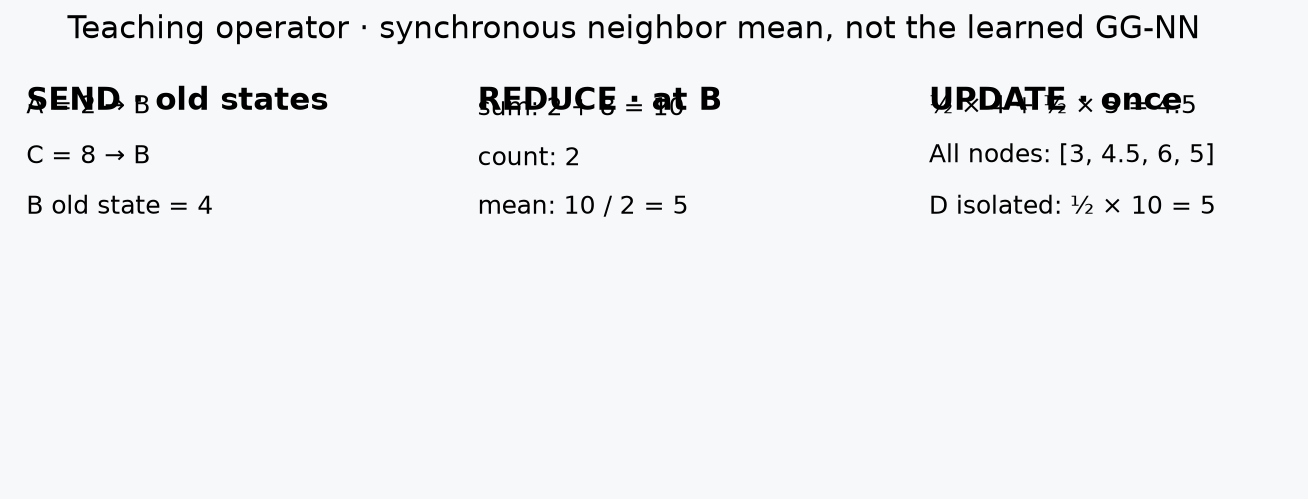</div><figcaption>Exact teaching trace; messages use old states and the isolated node receives a zero aggregate.</figcaption></figure>

At B, incoming messages are 2 and 8. Their mean is 5, so B becomes ½×4 + ½×5 = **4.5**. D receives zero and becomes **5**. This is an explicit empty-neighborhood convention, not a universal GNN rule; a residual-only update could instead preserve D.

**Intervention:** replace C=8 with C=20 in your live code.

Change C to 20. B should become 7.5; A should remain 3 after one round. Then inspect two rounds:

**Predict:** after two rounds A changes from 3.75 to 5.25. Explain the route.

Information can traverse at most one edge per local synchronous round. Global virtual nodes or all-pairs edges change that graph-distance statement. The learned molecular model below uses different messages and updates; this arithmetic example isolates routing.

**Implementation contract.** `edge_index[0]` contains sources and `edge_index[1]` destinations. `messages[E,D]` is reduced into `incoming[N,D]`. `index_add_` adds rows at destination indices, including repeated destinations. Here duplicate edges count as repeated messages; deduplicate upstream if your graph is intended to be simple.

```python
src, dst = edge_index
messages = message(h[dst], h[src], edge_attr)
incoming = aggregate(messages, dst, len(h), reduction="sum")
h_next = update(h, incoming)
```

In the notebook, implement the reducer, the synchronous mean update, and the graph readout. The checks include empty edges and node relabeling, so hard-coding this four-node answer cannot pass.

## 3 · Equivariance inside, invariance at the end

> **In plain terms.** If C becomes row zero, its output must become row zero too. The whole molecule has not changed, so its predicted property should stay the same.

**Permutation equivariance** means that relabeling the input nodes relabels the node outputs in the same way. **Permutation invariance** means that the graph output is unchanged. A shared message function, a symmetric reducer, and a shared update preserve equivariance. An invariant readout then produces an invariant graph prediction.

<figure class="mpnn-figure"><small>Scroll horizontally on narrow screens to inspect the full figure.</small><div class="figure-scroll" tabindex="0">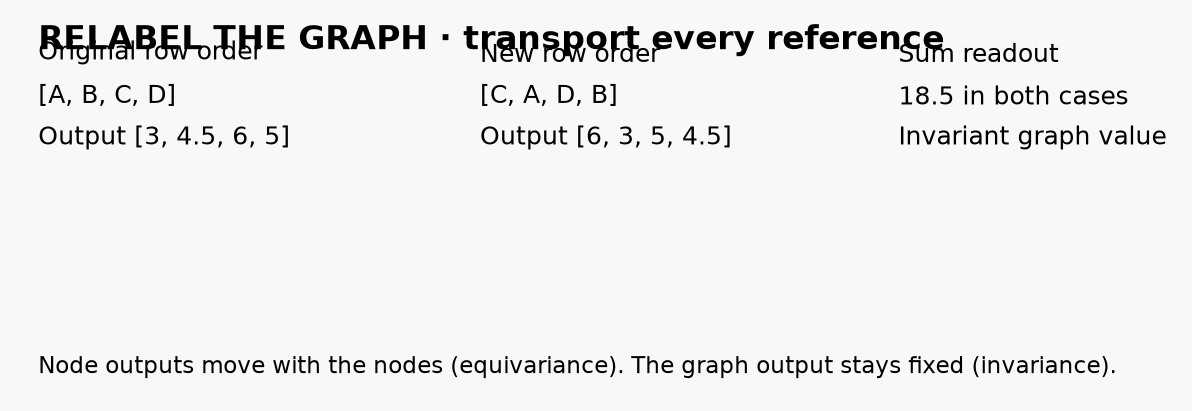</div><figcaption>Move features, endpoints and graph IDs together. Node outputs permute; graph sums stay fixed.</figcaption></figure>

**Worked example.** Store rows as [C,A,D,B] instead of [A,B,C,D]. The correct output becomes [6,3,5,4.5]. Its sum remains 18.5. Moving feature rows without remapping edge endpoints changes the actual graph and is not a symmetry test.

```python
permutation = torch.tensor([2, 0, 3, 1])  # new rows contain these old rows
inverse = torch.argsort(permutation)     # old index -> new index
x_new = x[permutation]
edges_new = inverse[edge_index]
# Also carry graph IDs with their nodes: batch_new = batch[permutation]
```

**Break it deliberately.** Remap the features but leave the edges fixed. Predict which check will fail. Then restore the endpoints, permute only edge order, and verify agreement within floating-point tolerance. Floating-point sums need not be bit-identical under a different addition order.

## 4 · GCN and GAT fit the same structure

The framework is a way to separate decisions, not a single architecture. The [MPNN supplement §1.1](https://proceedings.mlr.press/v70/gilmer17a/gilmer17a-supp.pdf) explicitly derives GCN as a special case. GAT arrived later; mapping it here is a retrospective application of the framework.

| Variant | Message from w to v | Aggregate | Update / output |
|---|---|---|---|
| Teaching mean | h𝑤 | incoming mean | ½hᵥ + ½mᵥ |
| GCN | (W h𝑤)/√(d̃ᵥd̃𝑤) | incoming sum, self-loops included | activation(mᵥ) |
| One-head GAT | αᵥ𝑤 W h𝑤 | incoming sum, self-loops included | activation(mᵥ) |
| Sparse GG-NN | two bond-specific matrix products | two sums, concatenated | recurrent gated update |

For GCN, d̃ counts neighbors after adding a self-loop exactly once. This is **not generally an ordinary mean**. In our chain with a self-loop, B receives 2/√6 + 4/3 + 8/√6 = 5.415816 when W=1. The ordinary self-inclusive mean is 14/3 = 4.666667. [Kipf & Welling](https://arxiv.org/abs/1609.02907).

**Predict:** why is the GCN weight not 1/degree(B)?

For GAT, α is a learned attention weight normalized over the destination's neighborhood. Scores are computed per edge, but the softmax denominator depends on all incoming edges for that destination. **This requires an additional neighborhood reduction before the weighted-message sum.** It is not a function of one isolated edge alone. A multi-head layer repeats this operation and combines heads. [Veličković et al.](https://arxiv.org/abs/1710.10903).

**CHECK your mapping.** Identify the reducer and self-loop convention before calling a layer “GCN.” Identify the softmax group before calling it “GAT.” The notebook instantiates the generic interface and checks a GCN layer against a dense normalized adjacency calculation.

## 5 · Model architecture · the sparse molecular GG-NN

> **In plain terms.** A double bond can transform its neighbor's state differently from a single bond. Gates decide how much of the old atom state to retain. Finally, each atom contributes to one molecular prediction.

<figure class="mpnn-figure"><small>Scroll horizontally on narrow screens to inspect the full figure.</small><div class="figure-scroll" tabindex="0">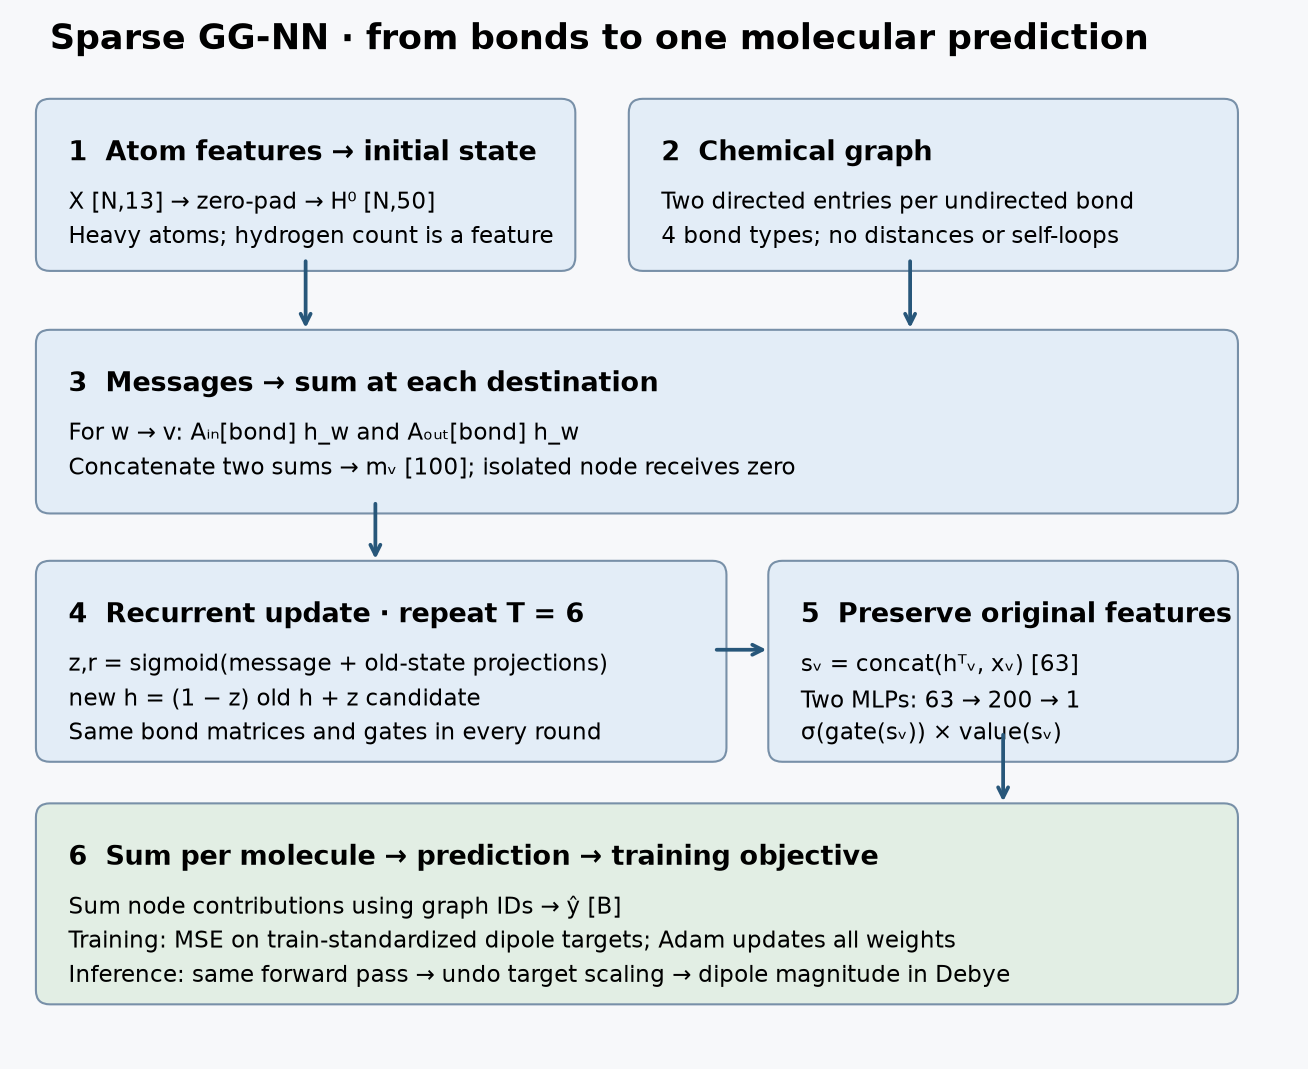</div><figcaption>Complete sparse GG-NN reconstruction: bond matrices, shared recurrent updates and gated graph readout. This is not the edge-network/set2set variant.</figcaption></figure>

**Inputs.** Each molecule is a graph of heavy atoms. Hydrogen count is a feature; hydrogens are not separate nodes in this reconstruction. Each atom has 13 features: five atom-type indicators, atomic number, acceptor and donor flags, aromaticity, three hybridization indicators, and hydrogen count. Each chemical bond becomes two directed edges. Bond labels are single, double, triple, or aromatic. There are no distances, self-loops, or nonbonded edges in this lane. The paper explores other input choices; see [§6 and Table 1](https://proceedings.mlr.press/v70/gilmer17a/gilmer17a.pdf).

**Initialization.** Pad the 13 observed coordinates with zeros to width 50. No pretrained checkpoint is loaded. Each run trains from initialized weights.

**Messages.** The [released GGNNMsgPass](https://github.com/brain-research/mpnn/blob/4a1f0ddea3cd7de5eebc96e509da2161624aaacd/mpnn.py) has separate incoming and outgoing matrix banks. A bond selects a 50×50 matrix in each bank. Each bank transforms the source state; two destination sums are concatenated into a 100-dimensional message. On this undirected molecular graph both banks see the same neighbors, but learn different transformations. On a directed graph the outgoing branch would require reversed routing; this molecular class is not a generic directed implementation.

**Update.** A sigmoid maps each gate coordinate into [0,1]. The reset gate filters the old state before candidate construction. The update gate interpolates between the old and candidate states:

```text
z = sigmoid(m Wz + h Uz)
r = sigmoid(m Wr + h Ur)
candidate = tanh(m W + (r ⊙ h) U)
h_new = (1 − z) ⊙ h + z ⊙ candidate
```

The source has no gate biases. We implement these equations directly: PyTorch's standard GRU cell uses a different reset placement in its candidate calculation. The same message and update weights are reused for six rounds in the smoke recipe. In the search, the number of rounds varies from three through eight.

**Readout.** Concatenate each final state with its original 13 features. Feed this 63-dimensional vector into two separate 63→200→1 networks with ReLU hidden activations. Multiply a sigmoid gate from one by the unrestricted scalar value from the other. Sum those contributions **within each molecule**, not across the batch. Original features remain available even after repeated updates.

**Training and inference.** Standardize the dipole targets using only training molecules. Minimize mean squared error in standardized units using Adam. Validation MAE chooses the checkpoint and trial. At inference undo target scaling; report mean absolute error in Debye, a unit of dipole moment. Loss uses training targets only. No training dropout is used. All model weights are trainable; the graph structure and atom features remain fixed.

> **Scope check.** This is the sparse GG-NN variant, not the paper's strongest edge-network + set2set model. The framework is shared, but messages, readout, and input information differ. The notebook exposes every forward-pass component and the entire reconstruction trainer.

## 6 · A named result and a reproducible attempt

The target is **Supplementary Table 3, GG-NN, μ**. Its reported error ratio is 3.94. The supplement gives a chemical-accuracy denominator of 0.1 Debye, so the corresponding MAE is **3.94 × 0.1 = 0.394 Debye**. That row is a sparse-graph baseline without spatial distances, not the best headline result.

The authors' [release README](https://github.com/brain-research/mpnn/tree/4a1f0ddea3cd7de5eebc96e509da2161624aaacd) supplies model definitions but no data reader or trainer. It says paper results used separate 50-trial searches. Therefore “run the defaults” cannot recover the historical experiment.

| Component | Published / released | This package |
|---|---|---|
| Data | 130,462 molecules in the paper | Modern QM9 archive, public exclusions, sanitization failures logged |
| Split | 10,000 validation; 10,000 test; remainder train | Fresh seeded molecule IDs saved explicitly; historical membership unavailable |
| Model | Sparse bond matrices, GRU, gated graph output | Complete visible reconstruction; NumPy equations and dense message checks |
| Objective | Standardized-target MSE, evaluate MAE | Train-only scaling, native-unit MAE |
| Search | 50 trials per model/target | `paper-budget`: 50 trials, fixed width 50; unreleased winning configurations remain a gap |
| Training | Batch 20, up to 3 million updates, Adam, linear LR decay | Same declared cap/schedule ranges in `paper-budget`; explicit modern optimizer/init and validation cadence |
| Selection | Validation early stopping and model selection | Best validation checkpoint under fixed cap; no patience-based termination |
| Evidence | 0.394 Debye for the named row | Smoke measurements below; full historical reproduction NOT_RUN |

**Author-reference smoke evidence; not student output or paper-result reproduction.**

| Split + initialization seed | Test MAE (Debye) | Updates | Status |
|---|---:|---:|---|
| 81 | 1.038806 | 40 | INCOMPARABLE |
| 82 | 1.115341 | 40 | INCOMPARABLE |
| 83 | 1.112676 | 40 | INCOMPARABLE |

Across these three smoke splits/runs: mean 1.088941, sample SD 0.043439 Debye. This is descriptive run variability, not dataset-level uncertainty.


The smoke uses the first 512 valid molecules in file order, then seeded splits. That cap is convenient for execution checks and is not representative sampling. Its three runs change both split and initialization seeds. Their spread is not a confidence interval for performance over datasets. Do not infer that this model beats a flat-table baseline: no such comparison was run.

**Reproduce from the repository root:**

```bash
python labs/_verify_l081.py
python labs/_run_l081.py --preset smoke --seed 81 --output /tmp/l081-new-smoke
python labs/_run_l081.py --preset closer --device cuda --output /tmp/l081-closer
# Full search/update budget; still a reconstruction with documented source gaps:
python labs/_run_l081.py --preset paper-budget --device cuda --output /tmp/l081-paper-budget
```

Use the pinned [environment and protocol](https://avistian.github.io/relational/labs/l081-reproduction.md). A run saves molecule IDs, trial configurations, validation histories, a selected checkpoint, test predictions, input hashes, and software versions. The code opens the test evaluation only after choosing the winning trial. Existing completed output directories are rejected.

> **Scope check.** Smoke execution is verified local evidence. The closer and paper-budget searches are NOT_RUN. Missing historical split/search/data-preparation details mean every reconstruction score remains INCOMPARABLE to the published row, even if numerically close. The independent equation tests do not establish full TensorFlow runtime or training parity.

## 7 · Lab and exit ticket

[Open the student notebook](https://avistian.github.io/relational/labs/0081-mpnn-framework.ipynb) · [Read the prepared lab](https://avistian.github.io/relational/labs/html/0081-mpnn-framework.html) · [Quick reference](https://avistian.github.io/relational/reference/0081-mpnn-framework.html).

1. Implement aggregation, synchronous mean update, and graph readout. Pass the routing and symmetry checks using your live functions.
2. Instantiate the generic interface; recover the hand trace. Instantiate GCN with normalized weights and compare with a dense operator. Explain why GAT needs destination-wise softmax.
3. Read and execute the full sparse GG-NN. Trace a forward pass and a backward pass; verify that your reducer is called by the model.
4. Submit the JSON exit artifact with the trace, relabeling error, graph outputs, and an interpretation of the source gaps. For a QM9 run, attach the run's split IDs, configurations, predictions and result ledger.

**Teach back:** explain why order-independent aggregation is necessary but does not by itself guarantee an order-independent graph prediction. Then explain why a scalar near 0.394 is insufficient proof of reproduction.

**Write your teach-back before comparing with the reference.**

Tomorrow, reconstruct the four operations from memory before opening the reference. After a week, rerun the relabeling test on a different graph with an isolated node. Next, lesson 82 studies GCN's normalization and node-classification protocol in detail. Ask the agent follow-up questions or paste your exit artifact for feedback; authoring this lesson does not mark your mastery complete.


In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
from torch.nn import functional as F

### TODO · aggregate

Reduce [E,D] edge messages to [N,D]; isolated nodes receive zero.

In [ ]:
def aggregate(messages, destination, n_nodes, reduction='sum'):
    # TODO: implement the contract above using the inputs.
    raise NotImplementedError("aggregate")

### CHECK · predict the outcome first

In [ ]:
m=torch.tensor([[2.],[8.],[8.]])
torch.testing.assert_close(aggregate(m,torch.tensor([1,1,1]),4,'mean'),torch.tensor([[0.],[6.],[0.],[0.]]))
assert aggregate(torch.empty(0,2),torch.empty(0,dtype=torch.long),3).shape==(3,2)
print('CHECK: multiple destinations, multiplicity and empty edges')

### TODO · mean_step

Synchronous L078 update: half self + half incoming-neighbor mean.

In [ ]:
def mean_step(h, edge_index):
    # TODO: implement the contract above using the inputs.
    raise NotImplementedError("mean_step")

### CHECK · predict the outcome first

In [ ]:
h=torch.tensor([[2.],[4.],[8.],[10.]])
e=torch.tensor([[0,1,1,2],[1,0,2,1]])
torch.testing.assert_close(mean_step(h,e),torch.tensor([[3.],[4.5],[6.],[5.]]))
p=torch.tensor([2,0,3,1]);inverse=torch.argsort(p)
torch.testing.assert_close(mean_step(h[p],inverse[e]),mean_step(h,e)[p])
print('CHECK: synchronous trace and node relabeling')

### TODO · graph_sum

Invariant graph readout; batch[i] is the graph ID of node i.

In [ ]:
def graph_sum(h, batch):
    # TODO: implement the contract above using the inputs.
    raise NotImplementedError("graph_sum")

### CHECK · predict the outcome first

In [ ]:
torch.testing.assert_close(graph_sum(torch.tensor([[2.],[4.],[8.],[10.]]),torch.tensor([0,0,0,1])),torch.tensor([[14.],[10.]]))
print('CHECK: graph membership prevents cross-molecule pooling')

### PROVIDED · GenericMPNN

Inject M(h_destination,h_source,e), U(h,m), and R(h,batch).

In [ ]:
class GenericMPNN(nn.Module):
    """Inject M(h_destination,h_source,e), U(h,m), and R(h,batch)."""
    def __init__(self,message,update,readout,reduction='sum',steps=1):
        super().__init__();self.message=message;self.update=update
        self.readout=readout;self.reduction=reduction;self.steps=steps

    def forward(self,h,edge_index,edge_attr,batch):
        src,dst=edge_index
        for _ in range(self.steps):
            m=self.message(h[dst],h[src],edge_attr)
            h=self.update(h,aggregate(m,dst,len(h),self.reduction))
        return h,self.readout(h,batch)

### PROVIDED · SourceGRU

Released bias-free gates; reset acts BEFORE recurrent multiplication.

torch.nn.GRUCell uses a different candidate equation and is not substituted.

In [ ]:
class SourceGRU(nn.Module):
    """Released bias-free gates; reset acts BEFORE recurrent multiplication.

    torch.nn.GRUCell uses a different candidate equation and is not substituted.
    """
    def __init__(self,width):
        super().__init__()
        for name,shape in [('w_z',(2*width,width)),('u_z',(width,width)),
                           ('w_r',(2*width,width)),('u_r',(width,width)),
                           ('w',(2*width,width)),('u',(width,width))]:
            p=nn.Parameter(torch.empty(shape));nn.init.xavier_uniform_(p)
            setattr(self,name,p)

    def forward(self,h,m):
        z=torch.sigmoid(m@self.w_z+h@self.u_z)
        r=torch.sigmoid(m@self.w_r+h@self.u_r)
        candidate=torch.tanh(m@self.w+(r*h)@self.u)
        return (1-z)*h+z*candidate

### PROVIDED · SparseGGNN

Four bond types, two message banks, tied recurrence, gated graph readout.

x: [N,13] Table-1-style atom features. Edges: both orientations of each bond.
No distance, virtual edge, self edge, or explicit hydrogen nodes in this lane.

In [ ]:
class SparseGGNN(nn.Module):
    """Four bond types, two message banks, tied recurrence, gated graph readout.

    x: [N,13] Table-1-style atom features. Edges: both orientations of each bond.
    No distance, virtual edge, self edge, or explicit hydrogen nodes in this lane.
    """
    def __init__(self,input_dim=13,width=50,steps=6,readout_width=200):
        super().__init__()
        if width<input_dim:raise ValueError('Hidden width must fit zero-padded atom features')
        self.width=width;self.steps=steps
        self.bond_in=nn.Parameter(torch.empty(4,width,width))
        self.bond_out=nn.Parameter(torch.empty(4,width,width))
        for bank in (self.bond_in,self.bond_out):
            for matrix in bank:nn.init.xavier_uniform_(matrix)
        self.update=SourceGRU(width)
        self.gate=nn.Sequential(nn.Linear(width+input_dim,readout_width),nn.ReLU(),nn.Linear(readout_width,1))
        self.value=nn.Sequential(nn.Linear(width+input_dim,readout_width),nn.ReLU(),nn.Linear(readout_width,1))
        for layer in [*self.gate,*self.value]:
            if isinstance(layer,nn.Linear):nn.init.xavier_uniform_(layer.weight);nn.init.zeros_(layer.bias)

    def message(self,h,edge_index,edge_type):
        src,dst=edge_index
        # Matrices act on column states, as in the released dense operator.
        incoming=torch.bmm(self.bond_in[edge_type],h[src,None].transpose(1,2)).squeeze(-1)
        outgoing=torch.bmm(self.bond_out[edge_type],h[src,None].transpose(1,2)).squeeze(-1)
        return torch.cat([aggregate(incoming,dst,len(h)),aggregate(outgoing,dst,len(h))],1)

    def forward(self,x,edge_index,edge_type,batch):
        h=F.pad(x,(0,self.width-x.shape[1]))
        for _ in range(self.steps):h=self.update(h,self.message(h,edge_index,edge_type))
        combined=torch.cat([h,x],1)
        return graph_sum(torch.sigmoid(self.gate(combined))*self.value(combined),batch).flatten()

## PROVIDED + CHECK · instantiate the framework

The GAT example is a one-head forward illustration with fixed scalar weights, not a trained GAT benchmark.

In [ ]:
# PROVIDED: recover the mean operator with the generic interface.
h=torch.tensor([[2.],[4.],[8.],[10.]])
e=torch.tensor([[0,1,1,2],[1,0,2,1]])
batch=torch.tensor([0,0,0,1])
generic=GenericMPNN(lambda hv,hw,edge:hw,lambda h,m:.5*h+.5*m,graph_sum,'mean')
node_out,graph_out=generic(h,e,None,batch)
torch.testing.assert_close(node_out,mean_step(h,e))
# GCN: add each self-loop once, then use symmetric degree normalization.
loops=torch.arange(len(h));ee=torch.cat([e,torch.stack([loops,loops])],1)
src,dst=ee;degree=torch.bincount(dst,minlength=len(h)).float()
weights=(degree[src]*degree[dst]).rsqrt()[:,None]
gcn=GenericMPNN(lambda hv,hw,w:hw*w,lambda h,m:m.relu(),graph_sum)
gcn_h,_=gcn(h,ee,weights,batch)
A=torch.zeros(4,4);A[dst,src]=1
S=degree.rsqrt()[:,None]*A*degree.rsqrt()[None,:]
torch.testing.assert_close(gcn_h,(S@h).relu())
# GAT one-head illustration W=1: softmax is grouped by DESTINATION.
score=torch.nn.functional.leaky_relu(h[dst,0]+h[src,0],negative_slope=.2)
alpha=torch.empty_like(score)
for v in range(len(h)):
    mask=dst==v;alpha[mask]=torch.softmax(score[mask],dim=0)
gat=GenericMPNN(lambda hv,hw,a:hw*a,lambda h,m:m,graph_sum)
gat_h,_=gat(h,ee,alpha[:,None],batch)
assert all(torch.isclose(alpha[dst==v].sum(),torch.tensor(1.)) for v in range(len(h)))
print('Mean nodes:',node_out.flatten().tolist(),'graph sums:',graph_out.flatten().tolist())
print('GCN B:',float(gcn_h[1]),'GAT B:',float(gat_h[1]))


In [ ]:
# CHECK: the live student reducer participates in the molecular model.
torch.manual_seed(81);torch.set_num_threads(1)
x=torch.randn(4,13);edge_type=torch.tensor([0,0,2,2])
model=SparseGGNN(width=16,steps=3,readout_width=24)
calls=[];student_aggregate=aggregate
def observed_aggregate(*args,**kwargs):
    calls.append(1);return student_aggregate(*args,**kwargs)
aggregate=observed_aggregate
y=model(x,e,edge_type,batch)
aggregate=student_aggregate
assert len(calls)==7, 'Two message reductions per round plus the graph readout'
p=torch.tensor([2,0,3,1]);inverse=torch.argsort(p)
y_perm=model(x[p],inverse[e],edge_type,batch[p])
torch.testing.assert_close(y,y_perm,atol=1e-6,rtol=1e-5)
y.square().sum().backward()
assert all(v.grad is not None and torch.isfinite(v.grad).all() for v in model.parameters())
print('CHECK: live reducer, graph invariance, finite gradients')


## EXIT · return an artifact, not a completion claim

Explain your results in your own words.

In [ ]:
# EXIT: attach this artifact and your written explanation for feedback.
import json
from pathlib import Path
exit_artifact={'lesson':81,'mean_trace':node_out.flatten().tolist(),'graph_outputs':graph_out.flatten().tolist(),'relabeling_max_error':float((y-y_perm).abs().max().detach()),'paper_target_mae_debye':.394,'paper_reproduction':'NOT_RUN','explanation_required':['equivariance versus invariance','why edge remapping matters','three historical protocol gaps']}
Path('l081-exit.json').write_text(json.dumps(exit_artifact,indent=2))
print(json.dumps(exit_artifact,indent=2))


## NEXT STEP · complete named-target reconstruction

The following loader, optimizer and selection code are visible and run your live model. Historical split/search details are missing. All presets remain INCOMPARABLE. Defaults below run a fresh short QM9 smoke; use a new output directory for each run. Download is about 44 MB. `paper-budget` requests 50 × 3 million updates and is not an interactive lesson task.

In [ ]:
import copy,csv,hashlib,json,random,time,urllib.request,zipfile

In [ ]:
from pathlib import Path

In [ ]:
import numpy as np

In [ ]:
import torch

In [ ]:
from torch_geometric.data import Data,Batch

In [ ]:
from rdkit import Chem,RDConfig

In [ ]:
from rdkit.Chem import ChemicalFeatures

In [ ]:
DATA_URL='https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/molnet_publish/qm9.zip'

In [ ]:
EXCLUDE_URL='https://ndownloader.figshare.com/files/3195404'

In [ ]:
EXPECTED={'qm9.zip':'f11d3f8ecc3097a72656a35c4847767852e6f346bf99a54619a1a3b6389ddc02','uncharacterized.txt':'3aa5115d540b356de94791d4a74c3bf1ed91c469ecf52a4f5d7cc0506fe02e24'}

### PROVIDED · sha256

Trace the inputs, intermediate tensors and returned values.

In [ ]:
def sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for b in iter(lambda:f.read(1<<20),b''):h.update(b)
    return h.hexdigest()

### PROVIDED · load_qm9

13 Table-1-style features, implicit H, public exclusions, recorded failures.

RDKit BaseFeatures donor/acceptor definitions replace the missing historical reader.

In [ ]:
def load_qm9(root,limit=None):
    """13 Table-1-style features, implicit H, public exclusions, recorded failures.

    RDKit BaseFeatures donor/acceptor definitions replace the missing historical reader.
    """
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    for name,url in [('qm9.zip',DATA_URL),('uncharacterized.txt',EXCLUDE_URL)]:
        path=root/name
        if not path.exists():
            tmp=path.with_suffix('.part');urllib.request.urlretrieve(url,tmp);tmp.replace(path)
        if sha256(path)!=EXPECTED[name]:raise ValueError(f'Input checksum mismatch: {name}')
    with zipfile.ZipFile(root/'qm9.zip') as z:
        for name in ('gdb9.sdf','gdb9.sdf.csv'):
            if not (root/name).exists():
                import shutil
                with z.open(name) as src,open(root/name,'wb') as dst:shutil.copyfileobj(src,dst)
            # Validate cached extraction against the already SHA256-pinned archive.
            import zlib
            crc=0
            with open(root/name,'rb') as f:
                for chunk in iter(lambda:f.read(1<<20),b''):crc=zlib.crc32(chunk,crc)
            if crc!=z.getinfo(name).CRC:raise ValueError(f'Cached extraction differs from archive: {name}')
    with open(root/'gdb9.sdf.csv') as f:targets={r['mol_id']:float(r['mu']) for r in csv.DictReader(f)}
    excluded=set()
    for line in (root/'uncharacterized.txt').read_text().splitlines()[9:-2]:
        words=line.split()
        if words and words[0].isdigit():excluded.add(int(words[0]))
    factory=ChemicalFeatures.BuildFeatureFactory(str(Path(RDConfig.RDDataDir)/'BaseFeatures.fdef'))
    bond_types={Chem.BondType.SINGLE:0,Chem.BondType.DOUBLE:1,Chem.BondType.TRIPLE:2,Chem.BondType.AROMATIC:3}
    atom_types=['H','C','N','O','F'];hybrids=[Chem.HybridizationType.SP,Chem.HybridizationType.SP2,Chem.HybridizationType.SP3]
    graphs=[];failed=[]
    for i,mol in enumerate(Chem.SDMolSupplier(str(root/'gdb9.sdf'),removeHs=False,sanitize=False)):
        if i+1 in excluded:continue
        if mol is None:failed.append(i+1);continue
        name=mol.GetProp('_Name')
        try:
            Chem.SanitizeMol(mol);mol=Chem.RemoveHs(mol);flags={'Donor':set(),'Acceptor':set()}
            for feature in factory.GetFeaturesForMol(mol):
                if feature.GetFamily() in flags:flags[feature.GetFamily()].update(feature.GetAtomIds())
            features=[]
            for a in mol.GetAtoms():
                j=a.GetIdx();features.append([float(a.GetSymbol()==t) for t in atom_types]+[a.GetAtomicNum(),float(j in flags['Acceptor']),float(j in flags['Donor']),float(a.GetIsAromatic())]+[float(a.GetHybridization()==t) for t in hybrids]+[a.GetTotalNumHs()])
            edges=[];kinds=[]
            for b in mol.GetBonds():
                u,v=b.GetBeginAtomIdx(),b.GetEndAtomIdx();edges.extend([(u,v),(v,u)]);kinds.extend([bond_types[b.GetBondType()]]*2)
            graphs.append(Data(x=torch.tensor(features,dtype=torch.float32),edge_index=torch.tensor(edges,dtype=torch.long).reshape(-1,2).t().contiguous(),edge_type=torch.tensor(kinds,dtype=torch.long),y=torch.tensor([targets[name]]),molecule_id=torch.tensor([i+1])))
        except (ValueError,RuntimeError,KeyError):failed.append(i+1);continue
        if limit is not None and len(graphs)>=limit:break
    info={'urls':[DATA_URL,EXCLUDE_URL],'input_sha256':{n:sha256(root/n) for n in ['qm9.zip','uncharacterized.txt']},'molecules_loaded':len(graphs),'failed_ids':failed,'limit':limit,'features':13,'explicit_hydrogens':False,'historical_population':130462,'population_match':len(graphs)==130462 if limit is None else False}
    return graphs,info

### PROVIDED · split_ids

Fresh label-blind IDs, not the unreleased historical split.

In [ ]:
def split_ids(n,seed=81,full=False):
    """Fresh label-blind IDs, not the unreleased historical split."""
    order=np.random.default_rng(seed).permutation(n);nv=10000 if full else max(1,n//10)
    if n<=2*nv:raise ValueError('Insufficient molecules for split')
    return {'train':order[2*nv:].tolist(),'validation':order[:nv].tolist(),'test':order[nv:2*nv].tolist()}

### PROVIDED · pack

Trace the inputs, intermediate tensors and returned values.

In [ ]:
def pack(graphs,ids,device):
    return Batch.from_data_list([graphs[int(i)] for i in ids]).to(device)

### PROVIDED · predict

Trace the inputs, intermediate tensors and returned values.

In [ ]:
def predict(model,graphs,ids,mean,std,device):
    model.eval();pred=[]
    with torch.no_grad():
        for start in range(0,len(ids),128):
            b=pack(graphs,ids[start:start+128],device)
            pred.extend((model(b.x,b.edge_index,b.edge_type,b.batch)*std+mean).cpu().tolist())
    return np.asarray(pred)

### PROVIDED · fit_trial

Normalized MSE, Adam, linear LR decay, validation-MAE checkpoint selection.

In [ ]:
def fit_trial(graphs,split,config,seed,device='cpu'):
    """Normalized MSE, Adam, linear LR decay, validation-MAE checkpoint selection."""
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    model=SparseGGNN(width=config['width'],steps=config['rounds']).to(device)
    y=np.array([float(graphs[i].y) for i in split['train']]);mean=float(y.mean());std=float(y.std())
    if not std>0:raise ValueError('Zero training-target variance')
    opt=torch.optim.Adam(model.parameters(),lr=config['lr']);rng=np.random.default_rng(seed)
    best=float('inf');history=[];order=rng.permutation(split['train']);cursor=0
    val_y=np.array([float(graphs[i].y) for i in split['validation']])
    for step in range(config['updates']):
        if cursor>=len(order):order=rng.permutation(split['train']);cursor=0
        ids=order[cursor:cursor+20];cursor+=20;b=pack(graphs,ids,device)
        fraction=step/max(1,config['updates']-1);decay=max(0,(fraction-config['decay_start'])/(1-config['decay_start']))
        for group in opt.param_groups:group['lr']=config['lr']*(1-decay*(1-config['final_factor']))
        model.train();opt.zero_grad();loss=((model(b.x,b.edge_index,b.edge_type,b.batch)-(b.y-mean)/std)**2).mean()
        if not torch.isfinite(loss):raise RuntimeError('Nonfinite training loss')
        loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),4.0);opt.step()
        if (step+1)%config['validate_every']==0 or step+1==config['updates']:
            mae=float(np.abs(predict(model,graphs,split['validation'],mean,std,device)-val_y).mean());history.append({'step':step+1,'validation_mae':mae})
            if mae<best:best=mae;best_state=copy.deepcopy({k:v.cpu() for k,v in model.state_dict().items()});best_step=step+1
    model.load_state_dict(best_state)
    return model,{'seed':seed,'config':config,'mean':mean,'std':std,'validation_mae':best,'best_step':best_step,'history':history}

### PROVIDED · run_reconstruction

Named-target attempt; test labels used only after validation selects one trial.

In [ ]:
def run_reconstruction(root,output,preset='smoke',seed=81,device='cpu'):
    """Named-target attempt; test labels used only after validation selects one trial."""
    import platform,rdkit,torch_geometric
    start=time.time();torch.set_num_threads(1);output=Path(output);output.mkdir(parents=True,exist_ok=True)
    if (output/'result.json').exists():raise FileExistsError('Use a new output directory to preserve prior evidence')
    limit,updates,trials={'smoke':(512,40,1),'closer':(12000,10000,3),'paper-budget':(None,3000000,50)}[preset]
    graphs,data=load_qm9(root,limit);split=split_ids(len(graphs),seed,full=limit is None)
    molecule_ids={k:[int(graphs[i].molecule_id) for i in v] for k,v in split.items()}
    (output/'split.json').write_text(json.dumps(molecule_ids,indent=2)+'\n')
    rng=np.random.default_rng(seed);records=[];best=float('inf')
    for trial in range(trials):
        config={'width':50,'rounds':int(rng.integers(3,9)) if trials>1 else 6,'lr':float(rng.uniform(1e-5,5e-4)) if trials>1 else .00013,'decay_start':float(rng.uniform(.1,.9)),'final_factor':float(rng.uniform(.01,1)),'updates':updates,'validate_every':20 if preset=='smoke' else 5000}
        model,record=fit_trial(graphs,split,config,seed+trial,device);records.append(record)
        if record['validation_mae']<best:
            best=record['validation_mae'];winner=trial;torch.save({'state_dict':model.state_dict(),'record':record},output/'selected.pt')
        (output/'trials.json').write_text(json.dumps(records,indent=2)+'\n');print(f'trial {trial+1}/{trials}: validation MAE {record["validation_mae"]:.5f} D',flush=True)
    selected=torch.load(output/'selected.pt',map_location=device,weights_only=False);record=selected['record']
    model=SparseGGNN(width=record['config']['width'],steps=record['config']['rounds']).to(device);model.load_state_dict(selected['state_dict'])
    predictions=predict(model,graphs,split['test'],record['mean'],record['std'],device);test_y=np.array([float(graphs[i].y) for i in split['test']]);mae=float(np.abs(predictions-test_y).mean())
    np.savez(output/'predictions.npz',molecule_id=molecule_ids['test'],prediction=predictions,target=test_y)
    result={'preset':preset,'status':'INCOMPARABLE','target':'Gilmer 2017 supplement Table 3 GG-NN mu','paper_mae_debye':.394,'test_mae_debye':mae,'test_error_ratio':mae/.1,'selected_trial':winner,'trials':records,'data':data,'split_seed':seed,'split_sha256':sha256(output/'split.json'),'prediction_sha256':sha256(output/'predictions.npz'),'seconds':time.time()-start,'versions':{'python':platform.python_version(),'torch':torch.__version__,'numpy':np.__version__,'rdkit':rdkit.__version__,'torch_geometric':torch_geometric.__version__},'deviations':['fresh split IDs','modern sanitized QM9 population and donor/acceptor definitions','fixed width 50; historical trial configurations unavailable','PyTorch initialization/Adam; no TensorFlow runtime parity','train-only target scaling; historical fit scope unstated','fixed validation interval; historical cadence unavailable'],'full_historical_reproduction':'NOT_RUN'}
    (output/'result.json').write_text(json.dumps(result,indent=2)+'\n');return result

In [ ]:
import tempfile
output=tempfile.mkdtemp(prefix='l081-notebook-')
result=run_reconstruction('data/cache/l081',output,preset='smoke',seed=81)
print({k:result[k] for k in ['status','test_mae_debye','full_historical_reproduction']})

In [ ]:
# Optional GPU reconstruction: never substitutes for historical protocol recovery.
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    assert torch.cuda.is_available(), 'Choose a GPU runtime for this search'
    result=run_reconstruction('data/cache/l081',tempfile.mkdtemp(prefix='l081-closer-'),preset='closer',seed=81,device='cuda')